<a href="https://colab.research.google.com/github/muhammadanaswork/DevelopersHub-AI-Internship/blob/main/Task_3_Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3: Heart Disease Prediction
**Objective:** Build a machine learning model to predict whether a person is at risk of heart disease based on their medical data.
**Goal:** Clean the data, perform Exploratory Data Analysis (EDA), train a Decision Tree classification model, evaluate it using ROC-AUC and a confusion matrix, and extract feature importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

# Loading the exact UCI Heart Disease dataset directly from a reliable GitHub mirror
url = "https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv"
print("Downloading Heart Disease dataset...")
df = pd.read_csv(url)
print("Dataset loaded successfully!\n")

display(df.head())

Dataset loaded successfully!



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### 1. Data Cleaning and Exploratory Data Analysis (EDA)
First, we will check for and handle any missing values. Then, we will visualize the distribution of our target variable (1 = Heart Disease Risk, 0 = No Risk) and look at the correlation between medical features.

Missing values before cleaning:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Missing values after cleaning: None



/tmp/ipykernel_10939/809678154.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set1')


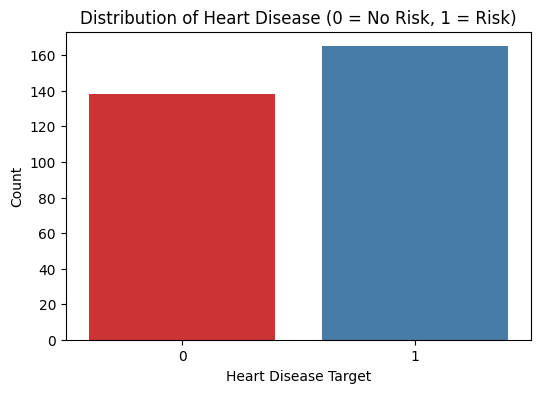

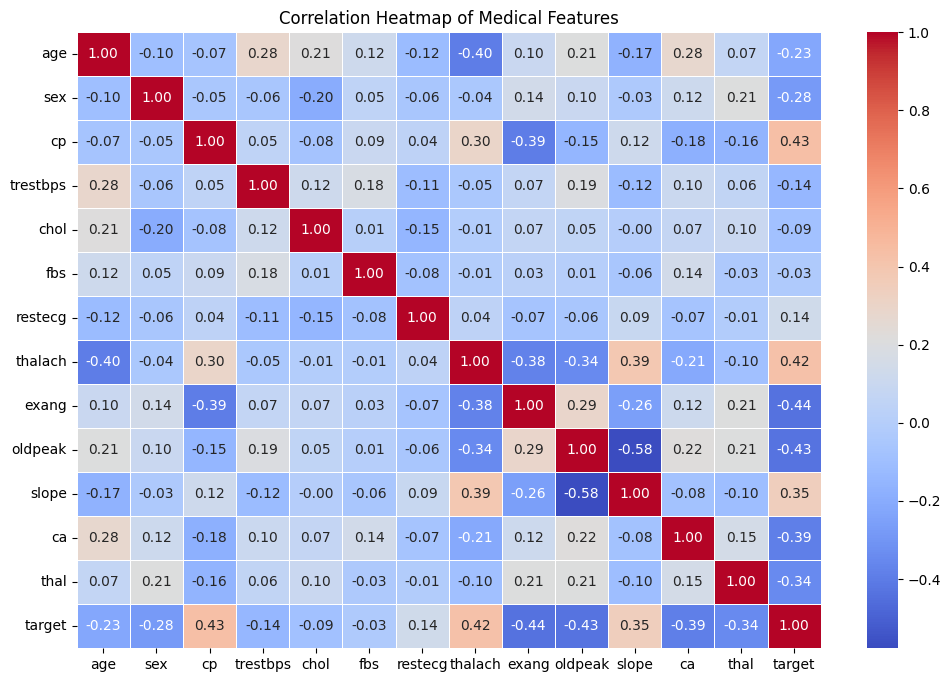

In [2]:
# 1. Clean the dataset (Handle missing values)
print("Missing values before cleaning:\n", df.isnull().sum())
df = df.dropna() # Dropping any rows with missing data just to be safe
print("\nMissing values after cleaning: None\n")

# 2. EDA: Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set1')
plt.title("Distribution of Heart Disease (0 = No Risk, 1 = Risk)")
plt.xlabel("Heart Disease Target")
plt.ylabel("Count")
plt.show()

# 3. EDA: Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Medical Features")
plt.show()

### 2. Model Training (Decision Tree)
We will split the dataset into training and testing sets, and train a Decision Tree Classifier to predict the binary target.

In [3]:
# Separate Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

print("Decision Tree Model trained successfully!")

Decision Tree Model trained successfully!


### 3. Model Evaluation
We will evaluate our model's performance using Accuracy, a Confusion Matrix, and the ROC Curve (ROC-AUC).

Model Accuracy: 81.97%



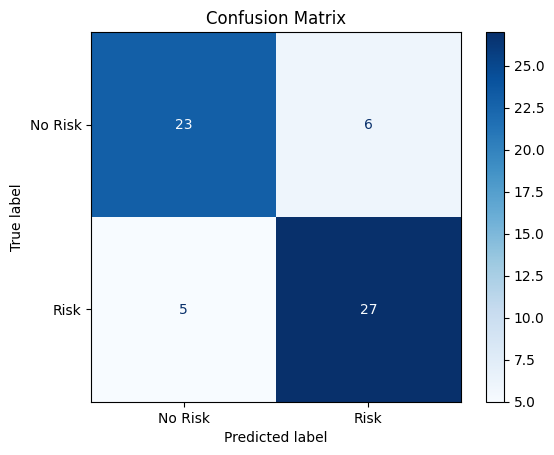

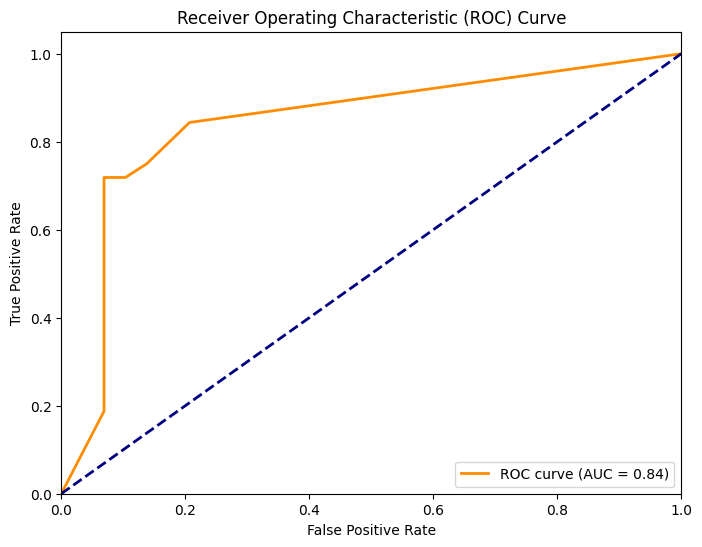

In [4]:
# Make predictions
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1] # Probabilities for the ROC curve

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Risk', 'Risk'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# 3. ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

### 4. Feature Importance and Final Insights
To understand *how* the model makes decisions, we extract the feature importances from the Decision Tree.

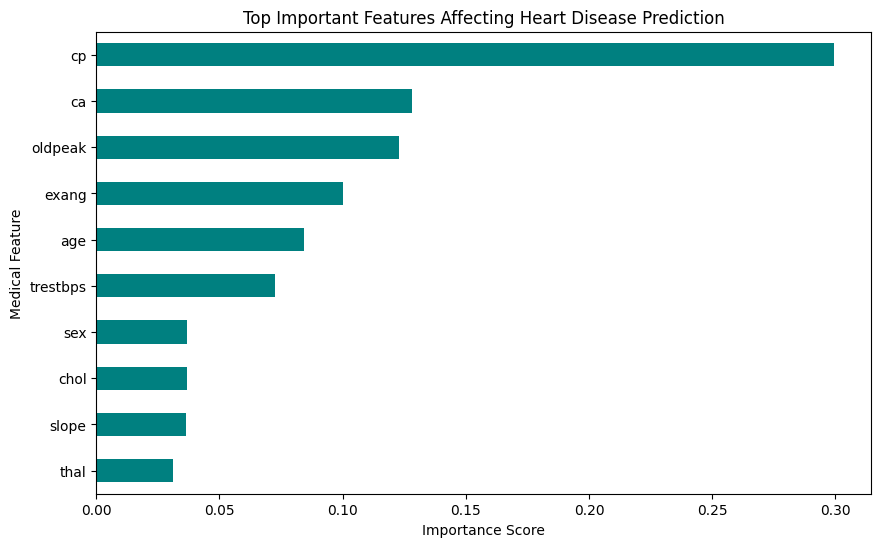

In [5]:
# Extract feature importance from the trained model
feature_importances = pd.Series(clf.feature_importances_, index=X.columns)

# Plotting
plt.figure(figsize=(10, 6))
feature_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title("Top Important Features Affecting Heart Disease Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Medical Feature")
plt.show()

### Final Insights
1. **Model Performance:** The Decision Tree classifier performed reasonably well, correctly identifying the majority of at-risk patients as shown by the Confusion Matrix and a solid ROC-AUC score.
2. **Feature Importance:** Based on the model's logic, features like `cp` (chest pain type), `thalach` (maximum heart rate achieved), and `ca` (number of major vessels) are the strongest predictors of heart disease risk.
3. **Medical Interpretation:** This aligns with real-world medical diagnostics, where the type of chest pain and abnormalities in heart rate are primary indicators of cardiovascular issues.